# Assignment: Benchmarking Neural Nets with the XOR Problem

## DS 6050 - School of Data Science - University of Virginia

## Alanna Hazlett 
## uwa6xv
## February 5th, 2025

In this assignment, you will implement your own neural networks to classify non-linear data from the XOR dataset. For deliverables, you must write code in Python/Tensorflow and submit **this** Jupyter Notebook file (.ipynb) to earn a total of 75 pts. Note that you must save your Notebook filename under this format: **yourUvaUserId_assignment_1_ann.ipynb**.



In [1]:
# You might want to use the following packages
import numpy as np
import os
#%tensorflow_version 2.17
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from functools import partial

2025-02-05 15:05:36.694351: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-05 15:05:37.006648: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-05 15:05:37.070395: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-05 15:05:37.589233: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
print(tf.__version__)
import sys
print(sys.version)
#print(keras.__version__)

2.17.0
3.12.3 (main, Sep 11 2024, 14:17:37) [GCC 13.2.0]


---
## 1. THE DATASET AND VISUALIZATION

We will use the non-linear toy data called the XOR dataset. You may use the code snippet below to generate the `train / validate / test` sets. Feel free to change the number of samples, and noise level. To keep the ratio between the sets consistent, please do not change the test_size and random_state parameters.



(720, 2)
(200, 2)
(80, 2)


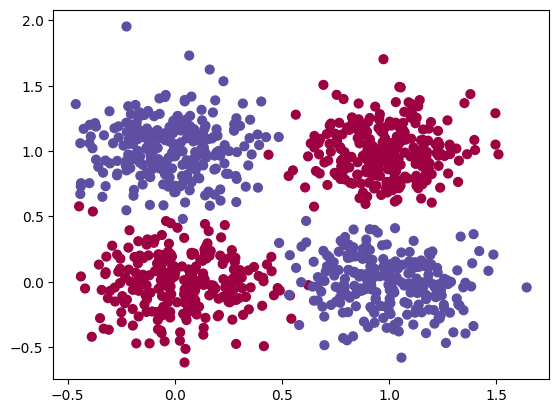

In [3]:
def make_xor(n_points):
    centers = np.array([[0,0],[0,1],[1,0],[1,1]])
    labels = np.array([0,1,1,0])
    data = np.array([]).reshape(-1,3)
    for center, label in zip(centers,labels):
        points = np.random.normal(loc=center,scale=0.2,size=(n_points//4,2))
        points_labels = np.hstack((points,label*np.ones(n_points//4).reshape((-1, 1))))
        data = np.vstack((data,points_labels))
    return (data[:,[0,1]],data[:,2])


X, y = make_xor(1000)
y=y.astype(np.int64)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=49)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size= 0.1, random_state=49)
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)
plt.scatter(X[:,0], X[:,1], s=40, c=y, cmap=plt.cm.Spectral)

In [4]:
# Testing a single observation
# print(X_train[7])
# plt.scatter(X_train[7,0], X[7,1])
# plt.show()


---
## 2. TRAIN A SIMPLE ANN FOR CLASSIFICATION TASK

Use the standard libarary of Neural Net on the training data, and then test the classifier on the test data. You will create a simple ANN with 3 layers: an Input Layer, a Hidden Layer, and an Output Layer. For each layer, you can specify the number of nodes appropriate for the XOR problem. Also, feel free to tune the network as you see fit. You have to report the accuracy
 of the network on the validation set.

In [5]:
# Your code here!
############################################
my_model = keras.models.Sequential([
           keras.layers.Input(shape=(2,)),
           keras.layers.Dense(100, activation='relu'),
           keras.layers.Dense(1, activation='sigmoid')])
############################################

2025-02-05 15:05:45.395212: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46581 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:01:00.0, compute capability: 8.6


In [6]:
# Parameters includes the biases
my_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 100)               300       
                                                                 
 dense_1 (Dense)             (None, 1)                 101       
                                                                 
Total params: 401 (1.57 KB)
Trainable params: 401 (1.57 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [7]:
optimizer = keras.optimizers.SGD(learning_rate=0.1)#, decay=0.0001)
my_model.compile(loss="binary_crossentropy",
                 optimizer="sgd",
                 metrics = ['accuracy'])

In [8]:
fit = my_model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val))

Epoch 1/50


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

20/23 [=========================>....] - ETA: 0s - loss: 0.7095 - accuracy: 0.4547 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
I0000 00:00:1738785948.522599  660421 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target

23/23 [==============================] - 3s 15ms/step - loss: 0.7101 - accuracy: 0.4500 - val_loss: 0.7149 - val_accuracy: 0.3750
Epoch 2/50
23/23 [==============================] - 0s 5ms/step - loss: 0.7057 - accuracy: 0.4847 - val_loss: 0.7112 - val_accuracy: 0.4625
Epoch 3/50
23/23 [==============================] - 0s 4ms/step - loss: 0.7015 - accuracy: 0.5361 - val_loss: 0.7077 - val_accuracy: 0.5125
Epoch 4/50
23/23 [==============================] - 0s 4ms/step - loss: 0.6975 - accuracy: 0.6167 - val_loss: 0.7043 - val_accuracy: 0.5250
Epoch 5/50
23/23 [==============================] - 0s 4ms/step - loss: 0.6935 - accuracy: 0.6611 - val_loss: 0.7008 - val_accuracy: 0.6000
Epoch 6/50
23/23 [==============================] - 0s 4ms/step - loss: 0.6897 - accuracy: 0.6722 - val_loss: 0.6975 - val_accuracy: 0.6250
Epoch 7/50
23/23 [==============================] - 0s 4ms/step - loss: 0.6861 - accuracy: 0.7028 - val_loss: 0.6944 - val_accuracy: 0.6375
Epoch 8/50
23/23 [============

In [9]:
accuracy = my_model.evaluate(X_test, y_test)
accuracy

7/7 [==============================] - 0s 2ms/step - loss: 0.5474 - accuracy: 0.9500


[0.547401487827301, 0.949999988079071]

In [10]:
predictions = my_model.predict(X_test)
predictions.reshape(20,10)

7/7 [==============================] - 0s 2ms/step


array([[0.57827264, 0.39762887, 0.5877216 , 0.67163485, 0.39705697,
        0.52824706, 0.5955923 , 0.5404651 , 0.56746423, 0.52622384],
       [0.41838992, 0.46127915, 0.44197056, 0.6342262 , 0.41316387,
        0.445029  , 0.39203137, 0.548204  , 0.40527034, 0.5694284 ],
       [0.47822273, 0.516183  , 0.78276783, 0.53122455, 0.477392  ,
        0.5527831 , 0.36686435, 0.51233906, 0.41646448, 0.62926847],
       [0.5945307 , 0.55477333, 0.4029874 , 0.39793488, 0.5665261 ,
        0.37910643, 0.49508527, 0.39046428, 0.49895108, 0.6288536 ],
       [0.5767671 , 0.6374112 , 0.3581365 , 0.39791983, 0.67179775,
        0.36570928, 0.55011827, 0.5290304 , 0.58872265, 0.53851455],
       [0.43627325, 0.4058504 , 0.6326826 , 0.53746897, 0.46539542,
        0.50341   , 0.42953363, 0.4282211 , 0.43866068, 0.43910894],
       [0.41878337, 0.39244097, 0.35877937, 0.41263366, 0.42023015,
        0.3969497 , 0.43814158, 0.58927006, 0.42370558, 0.59544265],
       [0.36511028, 0.5366024 , 0.5273485

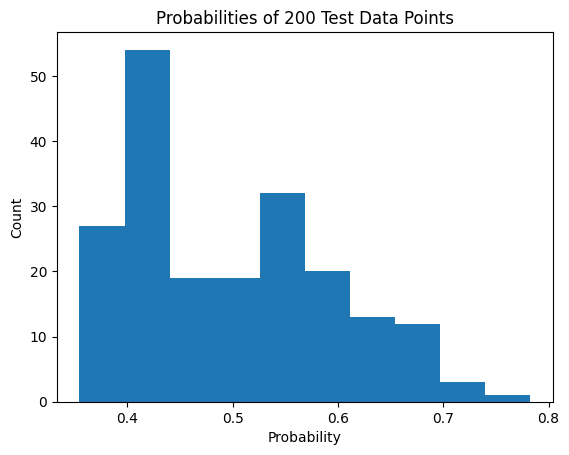

In [11]:
plt.hist(predictions)
plt.title("Probabilities of 200 Test Data Points")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()

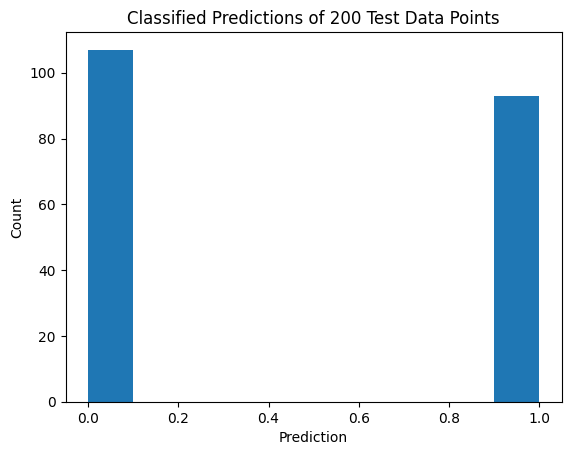

In [12]:
plt.hist((predictions > 0.5).astype(int))
plt.title("Classified Predictions of 200 Test Data Points")
plt.xlabel("Prediction")
plt.ylabel("Count")
plt.show()

- - -
## 3. IMPLEMENTING YOUR OWN SIMPLE NEURAL NETWORK

Now that you see how the standard library ANN performs on the XOR dataset, you will attempt to implement your own version of the neural network. To help you, a template has been created including the backpropagation. Essentially, you will get the backward gradients for free. However, please note that the backprop implementation assumes usage of tanh activation for the hidden layer and softmax for the output layer. There are some subtasks which you need to implement in order to get the network to work properly.

In [13]:
from sklearn.base import BaseEstimator #BaseEstimator provides among other things a default implementation for the get_params and set_params methods
from sklearn.preprocessing import OneHotEncoder
import numpy as np

class MyNeuralNet(BaseEstimator):
    """Your implementation of a simple neural network"""

    def __init__ (self, n0, n1, n2, alpha=0.01):
        """
        @param: n0: Number of nodes in the input layer
        @param: n1: Number of nodes in the hidden layer
        @param: n2: Number of nodes in the output layer
        @param: alpha: The Learning Rate
        """
        self.n0 = n0
        self.n1 = n1
        self.n2 = n2
        # SUBTASK 1: Initialize the parameters to random values.
        np.random.seed(42)
        ############## YOUR CODE HERE ###############
        self.W1 = np.random.normal(0,1, size=(n1,n0))                       
        self.b1 = np.random.normal(0,1, size=(n1,1))                                          
        self.W2 = np.random.normal(0,1, size=(n2,n1))                       
        self.b2 = np.random.normal(0,1, size=(n2,1))                                          

        # Configure the learning rate
        self.alpha = alpha
        # One-hot encoder for labels
        self.encoder = OneHotEncoder(sparse_output=False)

    def forward_pass(self, X):
        """
        Pass the signal forward through the layers.
        @param: X: feature
        @return: A1: saved value of the output of the hidden layer
        @return: A2: activated return value of the output layer.
        """
        # SUBTASK 2: Implement Forward propagation.
        # Note: that you must implement tanh activation for the hiden layer
        # and softmax for the output layer
        ############## YOUR CODE HERE ###############
        #Z1 = np.add(np.matmul(self.W1,X), self.b1)                     #W1 X +b1
        Z1 = np.add(np.dot(self.W1,X), self.b1)
        A1 = np.tanh(Z1)                                               #tanh(Z1)
        #Z2 = np.add(np.matmul(self.W2,A1),self.b2)                    #W2 A1 +b2
        Z2 = np.add(np.dot(self.W2,A1),self.b2)
        A2 = np.exp(Z2)/np.sum(np.exp(Z2), axis = 0, keepdims = True)                          #softmax(z2)
        

        return A1, A2


    def loss(self, X, y):
        """
        Evaluate the total loss on the dataset
        @param: X: features
        @param: y: labels
        @return: L: the loss value
        """


        # SUBTASK 3: Calculate the loss using Cross-Entropy
        # You will need to return the average loss on the data
        # Hint: Use A2 to calculate the loss
        A1, A2 = self.forward_pass(X)
        # Another Hint: First, you may want to convert the label y into a one-hot vector
        Y = self.one_hot(y)

        ############## YOUR CODE HERE ###############
        L = 0
        m = y.shape[0] #len(y)
        L = (1/m) * np.sum(-y * np.log(A2) - (1-y) * np.log(1 - A2)) # Binary Cross Entropy  

        return L

    def backward_pass(self, A1, A2, X, y):
        """
        @param: X: feature
        @param: y: label
        @param: A1: saved value of the output of the hidden layer
        @param: a2: activated return value of the output layer.

        @return: dW1: the loss gradient of W1
        @return: db1: the loss gradient of b1
        @return: dW2: the loss gradient of W2
        @return: db2: the loss gradient of b2
        """

        # You DO NOT CHANGE this function, ...
        # unless you are advanced and want to use different activation function for your forward pass
        # This is an elegant partial derivative of cross entropy with softmax
        # Ref document: https://deepnotes.io/softmax-crossentropy
        m   = y.shape[0]
        dZ2 = A2 - self.one_hot(y)
        dW2 = np.dot(dZ2, A1.T)/m
        db2 = np.sum(dZ2, axis=1, keepdims=True)/m
        dZ1 = np.multiply( np.dot( self.W2.T, dZ2), 1-np.power( A1, 2))
        dW1 = np.dot(dZ1, X.T)/m
        db1 = np.sum(dZ1, axis=1, keepdims=True)/m

        return dW1, db1, dW2, db2


    def fit(self, X, y , epochs, X_val, Y_val):
        """
        Learns parameters for the neural network and returns the model.

        @param: X: the training feature
        @param: y: the train label
        @param: epochs: Number of passes through the training data for gradient descent
        @param: X_val: the feature of validation set
        @param: y_val: the label of validation set
        """

        # Input checks: X and X_val needs to be in the form of n0 x m
        if (X.shape[0] > X.shape[1]): X = X.T
        if (X_val.shape[0] > X_val.shape[1]): X_val = X_val.T

        # Gradient descent
        for i in range(0, epochs):

            # SUBTASK 4: Compute the forward, backward, and gradient descent parameter update
            # Step 1: Forward pass
            ############## YOUR CODE HERE ###############
            A1, A2 = self.forward_pass(X)

            # Step 2: Backward pass
            dW1, db1, dW2, db2 = self.backward_pass(A1, A2, X, y)

            # Step 3: Gradient Descent
            self.W1 = self.W1 - self.alpha*dW1
            self.b1 = self.b1 - self.alpha*db1
            self.W2 = self.W2 - self.alpha*dW2
            self.b2 = self.b2 - self.alpha*db2

            # Print the loss and validation accuracy every 10 epochs.
            if i % 10 == 0:
                print("Epoch %i/%i - loss: %f - accuracy: %f - val_loss: %f - val_accuracy: %f"
                      %(i,epochs, self.loss(X, y), self.evaluate(X, y),
                        self.loss(X_val, y_val), self.evaluate(X_val,y_val)))

    def predict(self, X):
        """
        Predict label vector y
        """
        # check X for the form of n0 x m
        if (X.shape[0] > X.shape[1]): X = X.T

        # SUBTASK 5: Implement the prediction process.
        # Hint: It should include a forward pass, and then use the class with higher probability.
        ############## YOUR CODE HERE ###############
        A1, A2 = self.forward_pass(X)
        m = len(A2)
        y_hat = np.argmax(A2, axis = 0)
        return y_hat


    def evaluate(self, X, y):
        """
        Evaluate the accuracy of the model
        """
        m = y.shape[0]
        y_hat = self.predict(X)
        correct_y = (y_hat == y).astype(int)

        return sum(correct_y)/m


    def one_hot(self, y):
        """
        Utility function: Convert a label vector to one-hot vector
        """
        Y = self.encoder.fit_transform(y.reshape(len(y),1))
        return Y.T # Transpose to get into same shape 1 x m


    def plot_decision_boundary(self, X, y):
        """
        Utility Function: Plot a decision boundary for visualization purpose.
        If you don't fully understand this function don't worry, it just generates the contour plot below.
        """
        # Set min and max values and give it some padding
        x_min, x_max = X[:,0].min() - .5, X[:,0].max() + .5
        y_min, y_max = X[:,1].min() - .5, X[:,1].max() + .5
        h = 0.01
        # Generate a grid of points with distance h between them
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        # Predict the function value for the whole gid
        data_grid= np.c_[xx.ravel(), yy.ravel()]
        Z = self.predict(data_grid)
        Z = Z.reshape(xx.shape)

        # Plot the contour and training examples
        plt.contourf(xx, yy, Z, cmap=plt.cm.Pastel1)
        plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.Spectral)

---
## 4. REFLECT ON THE COMPARISON BETWEEN YOUR IMPLEMENTATION TO THE STANDARD LIBRARY
Now that you have implemented your own Neural Net class, let's use it! Create at least 3 instances of your Neural Net class, each with a different number of nodes in the hiden layer, tune it with the appropriate learning rate and number of iteration. You will test their performance in the XoR dataset and report the test accuracy metrics for each instance of your neural network.

Based on the test accuracy, compare your models with the standard library version.

Epoch 0/50 - loss: 7.093809 - accuracy: 0.537500 - val_loss: 7.338805 - val_accuracy: 0.387500
Epoch 10/50 - loss: 5.617679 - accuracy: 0.504167 - val_loss: 5.652664 - val_accuracy: 0.437500
Epoch 20/50 - loss: 4.578811 - accuracy: 0.488889 - val_loss: 4.518587 - val_accuracy: 0.450000
Epoch 30/50 - loss: 3.647062 - accuracy: 0.479167 - val_loss: 3.531533 - val_accuracy: 0.450000
Epoch 40/50 - loss: 2.927279 - accuracy: 0.493056 - val_loss: 2.805543 - val_accuracy: 0.500000
Accuracy on the test set is  0.53


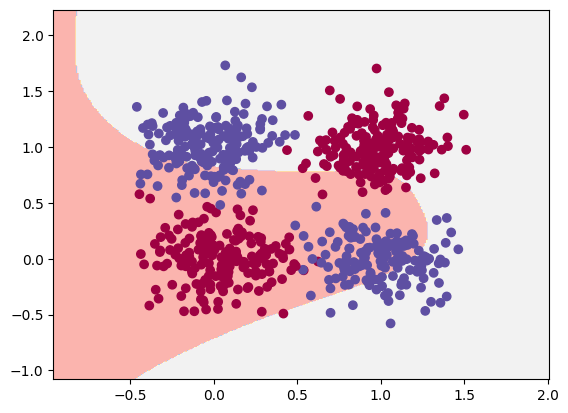

In [14]:
# MODEL 1 here
n0 = 2# input layer dimensionality
n1 = 100# hiden layer dimensionality
n2 = 2# output layer dimensionality
alpha = 0.01# learning rate for gradient descent
epochs = 50# number of iteration/epochs

# Build a model with 3 layers
myModel1 = MyNeuralNet(n0, n1, n2, alpha);
myModel1.fit(X_train, y_train, epochs, X_val, y_val)
print("Accuracy on the test set is ", myModel1.evaluate(X_test, y_test))

# Plot the decision boundary
myModel1.plot_decision_boundary(X_train, y_train)


Epoch 0/50 - loss: 5.705634 - accuracy: 0.493056 - val_loss: 5.659383 - val_accuracy: 0.462500
Epoch 10/50 - loss: 2.053584 - accuracy: 0.915278 - val_loss: 2.053871 - val_accuracy: 0.937500
Epoch 20/50 - loss: 2.311826 - accuracy: 0.944444 - val_loss: 2.318404 - val_accuracy: 0.950000
Epoch 30/50 - loss: 2.535666 - accuracy: 0.965278 - val_loss: 2.543452 - val_accuracy: 0.975000
Epoch 40/50 - loss: 2.726259 - accuracy: 0.970833 - val_loss: 2.733991 - val_accuracy: 0.975000
Accuracy on the test set is  0.96


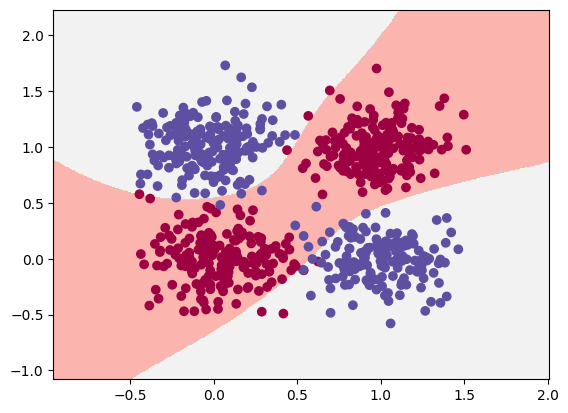

In [15]:
# MODEL 2 here
############## YOUR CODE HERE ###############
n0 = 2# input layer dimensionality
n1 = 100# hiden layer dimensionality
n2 = 2# output layer dimensionality
alpha = 0.1# learning rate for gradient descent
epochs = 50# number of iteration/epochs

# Build a model with 3 layers
myModel1 = MyNeuralNet(n0, n1, n2, alpha);
myModel1.fit(X_train, y_train, epochs, X_val, y_val)
print("Accuracy on the test set is ", myModel1.evaluate(X_test, y_test))

# Plot the decision boundary
myModel1.plot_decision_boundary(X_train, y_train)
#############################################

Epoch 0/50 - loss: 5.446954 - accuracy: 0.501389 - val_loss: 5.289611 - val_accuracy: 0.462500
Epoch 10/50 - loss: 4.033253 - accuracy: 0.526389 - val_loss: 4.245907 - val_accuracy: 0.637500
Epoch 20/50 - loss: 3.252554 - accuracy: 0.969444 - val_loss: 3.306478 - val_accuracy: 0.987500
Epoch 30/50 - loss: 3.424667 - accuracy: 0.972222 - val_loss: 3.437741 - val_accuracy: 0.987500
Epoch 40/50 - loss: 3.573434 - accuracy: 0.975000 - val_loss: 3.586410 - val_accuracy: 0.987500
Accuracy on the test set is  0.965


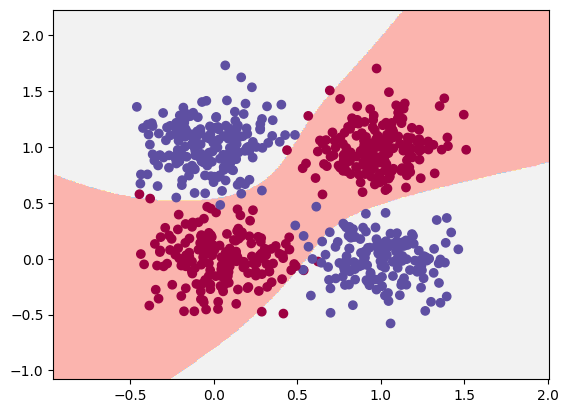

In [16]:
# MODEL 3 here
############## YOUR CODE HERE ###############
n0 = 2# input layer dimensionality
n1 = 100# hiden layer dimensionality
n2 = 2# output layer dimensionality
alpha = 0.15# learning rate for gradient descent
epochs = 50# number of iteration/epochs

# Build a model with 3 layers
myModel1 = MyNeuralNet(n0, n1, n2, alpha);
myModel1.fit(X_train, y_train, epochs, X_val, y_val)
print("Accuracy on the test set is ", myModel1.evaluate(X_test, y_test))

# Plot the decision boundary
myModel1.plot_decision_boundary(X_train, y_train)
#############################################

In [17]:
# COMPARISONS OF THESE MODELS WITH THE STANDARD LIBRARY MODEL IN TASK 2

## Reflection
Write at least a paragraph answering these prompts: 

#### How did your own network perform? 
I believe my network performed quite well. I achieved training and test accuracy over 0.95 and validation of 0.93 or above (these values could change slightly on each run of the code). The loss was generally the lowest for my second model, with an alpha value of 0.1, but the third model wasn't too far behind. I believe any alpha value somewhere between 0.1 and 0.15 would be sufficient. Trying values outside of this range resulted in poorer results like in model one, where the accuracy only reaches around 0.5. I tried alpha values greater than 0.15 as well, these retained high levels of accuracy, but the loss increases.  

I tried different number of nodes in the hidden layer (see models below for reference), with n0=2, n2=2, alpha=0.1, epochs=50. With n1=10 the accuracy is low, about 0.9-0.95 and the loss is low at about 0.16. At n1=50 we see improvement in the accuracy to 0.92-0.985. At n1=200 accuracy is about 0.95-0.98, but loss has increased significantly. I found that an appropriate number of nodes in our hidden layer is about 100, as this resulted in high accuracy.

I also tried different number of epochs (see models below if you'd like), with n0=2, n1=100, n2=2, and alpha=0.1. Low number of epochs doesn't provide enough iterations to obtain good accuracy. A high number of epochs the accuracy improves and somewhat levels off and the loss increases. I found that about 50 epochs seems sufficient for this data and network. 

Overall I liked model 2 as being a generally well performing model for MyNeuralNet models. This one is the most similiar to my tensorflow model, with the same number of hidden layers, learning rate, and number of epochs. Directly comparing these two we see that the tensorflow model has higher accuracy for training, validation, and test. The values are similar, but the tensorflow model is about 0.02 higher for each of these. Additionally the loss values are a lot smaller with values 0.4-0.5 compared to around 2.5 for MyNeuralNet. 

#### Are there any major differences between the implementations? 
Yes, the tensorflow/keras implementation utilizes ReLu as it's activation function. This means that it transforms any values that were less than zero into zero and all positive values remain the same. MyNeuralNet utilizes tanh for the activation function. Tanh is a smooth function that for all real x values y can be between -1 and 1. The benefit to tanh being smooth is that the derivative is always able to be calculated, which means that stochastic gradient descent works well with this function. 

Additionally the tensorflow/keras utilizes the sigmoid function. This means that the output from this network is a single value for each observation. This value is the probability of the observation belonging to the '1' class. This is evident in the two bar charts I have created, where one displays the probabilities and the other displays the number of observations in each class. For MyNeuralNet we utilized the softmax, which is similar, however it calculates the probability of an observation belonging to a certain class. This means that there are 2 outputs for each observation as we have 2 classes (0 and 1). The observation has a probability of belonging to the 0 class and an observation belonging to the 1 class. 

#### Finally, reflecting on your experience implementing a learning algorithm for this assignment (Was it hard/easy/fun?, From which part did you learn the most?)!

The most difficult part of this assignment was dealing with the different dimensions. I had a couple of dimension issues, but oddly enough the one that tripped me up the most was related to the pre-written code. All of the methods that depended on the forward pass had one or both of these lines:

if (X.shape[0] > X.shape[1]): X = X.T

if (X_val.shape[0] > X_val.shape[1]): X_val = X_val.T

This caused me problems, because I was writing one method at a time and checking the results to make sure that they would operate how I expected and outputted what I expected. In the case of the forward pass I was having issues with 

test.forward_pass(np.array([[1,1],[1,1],[0,1],[1,0]])) 

but 

test.forward_pass(np.array([[1,1],[1,1],[0,1],[1,0]]).T) 

would work. 

This was the opposite of what I expected as the X matrix should be a 2 by something, not something by 2 in order to left multiply by our weight matrix. Due to the way the forward pass is actually implemented in  making the model this is the way the code is written out. I believe one way to make this more efficient may be to include the X transpose line in the forward pass method rather than all of the methods that call the forward pass. 

Another aspect that was difficult for me during this assignment was dealing with version issues of tensorflow. I do not have any experience with Google Colab and I thought the reason the material was provided on Colab was because the tensorflow versions were a non-issue there, however that is not the case. I created a virtual environment on my local system, however I also had some trouble pip installing the correct tensorflow version there as well; to be specific the terminal gave an error that tensorflow==2.17 did not exist. It was not until I had access to Rivanna with the tensorflow 2.17 kernel that version issues became a problem of the past. 

These two difficulties provided me a lot to learn from. I really got in the weeds of the code for MyNeuralNet and examined what was really happening and the flow of the code. The version control issues lead me to learn how to create a virtual environment on my own, something I have never done before. I learned that these are used quite a lot actually alongside packaging code, which I have done before. 

Generally, for me I would say it is difficult at first as there are just a lot of different aspects to learn all at once. Having a little more understanding of tensorflow/keras it is slightly easier now. 

### Testing different number of nodes in hidden layer

Epoch 0/50 - loss: 1.836669 - accuracy: 0.415278 - val_loss: 1.775442 - val_accuracy: 0.375000
Epoch 10/50 - loss: 1.493348 - accuracy: 0.552778 - val_loss: 1.479449 - val_accuracy: 0.500000
Epoch 20/50 - loss: 1.478939 - accuracy: 0.806944 - val_loss: 1.465000 - val_accuracy: 0.675000
Epoch 30/50 - loss: 1.526618 - accuracy: 0.905556 - val_loss: 1.508222 - val_accuracy: 0.850000
Epoch 40/50 - loss: 1.585125 - accuracy: 0.944444 - val_loss: 1.563769 - val_accuracy: 0.925000
Accuracy on the test set is  0.95


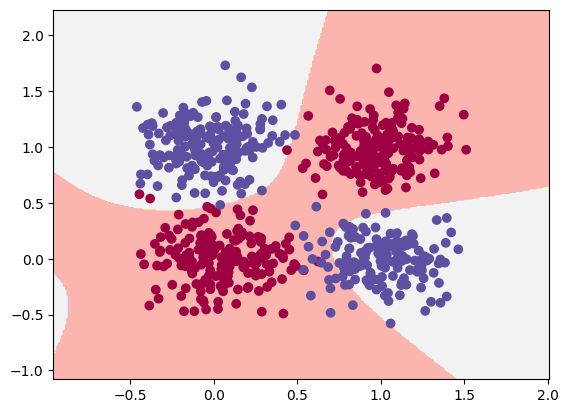

In [18]:
n0 = 2# input layer dimensionality
n1 = 10# hiden layer dimensionality
n2 = 2# output layer dimensionality
alpha = 0.1# learning rate for gradient descent
epochs = 50# number of iteration/epochs

# Build a model with 3 layers
myModel1 = MyNeuralNet(n0, n1, n2, alpha);
myModel1.fit(X_train, y_train, epochs, X_val, y_val)
print("Accuracy on the test set is ", myModel1.evaluate(X_test, y_test))

# Plot the decision boundary
myModel1.plot_decision_boundary(X_train, y_train)

Epoch 0/50 - loss: 2.921168 - accuracy: 0.494444 - val_loss: 2.808556 - val_accuracy: 0.537500
Epoch 10/50 - loss: 1.507926 - accuracy: 0.831944 - val_loss: 1.495672 - val_accuracy: 0.762500
Epoch 20/50 - loss: 1.721619 - accuracy: 0.943056 - val_loss: 1.722364 - val_accuracy: 0.925000
Epoch 30/50 - loss: 1.939614 - accuracy: 0.969444 - val_loss: 1.947913 - val_accuracy: 0.975000
Epoch 40/50 - loss: 2.130586 - accuracy: 0.976389 - val_loss: 2.143687 - val_accuracy: 0.987500
Accuracy on the test set is  0.975


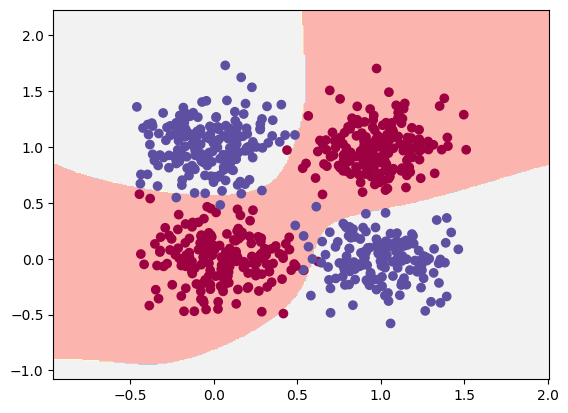

In [19]:
n0 = 2# input layer dimensionality
n1 = 50# hiden layer dimensionality
n2 = 2# output layer dimensionality
alpha = 0.1# learning rate for gradient descent
epochs = 50# number of iteration/epochs

# Build a model with 3 layers
myModel1 = MyNeuralNet(n0, n1, n2, alpha);
myModel1.fit(X_train, y_train, epochs, X_val, y_val)
print("Accuracy on the test set is ", myModel1.evaluate(X_test, y_test))

# Plot the decision boundary
myModel1.plot_decision_boundary(X_train, y_train)

Epoch 0/50 - loss: 6.881243 - accuracy: 0.404167 - val_loss: 6.324020 - val_accuracy: 0.362500
Epoch 10/50 - loss: 6.721867 - accuracy: 0.606944 - val_loss: 6.184003 - val_accuracy: 0.487500
Epoch 20/50 - loss: 4.976647 - accuracy: 0.986111 - val_loss: 4.967622 - val_accuracy: 1.000000
Epoch 30/50 - loss: 5.056323 - accuracy: 0.988889 - val_loss: 5.065613 - val_accuracy: 1.000000
Epoch 40/50 - loss: 5.138354 - accuracy: 0.990278 - val_loss: 5.152953 - val_accuracy: 1.000000
Accuracy on the test set is  1.0


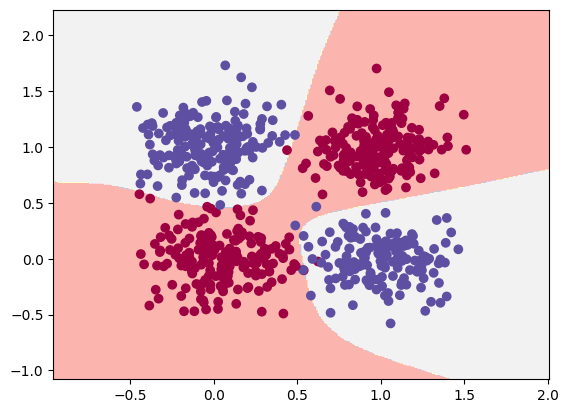

In [20]:
n0 = 2# input layer dimensionality
n1 = 200# hiden layer dimensionality
n2 = 2# output layer dimensionality
alpha = 0.1# learning rate for gradient descent
epochs = 50# number of iteration/epochs

# Build a model with 3 layers
myModel1 = MyNeuralNet(n0, n1, n2, alpha);
myModel1.fit(X_train, y_train, epochs, X_val, y_val)
print("Accuracy on the test set is ", myModel1.evaluate(X_test, y_test))

# Plot the decision boundary
myModel1.plot_decision_boundary(X_train, y_train)

### Testing different number of epochs

Epoch 0/10 - loss: 5.705634 - accuracy: 0.493056 - val_loss: 5.659383 - val_accuracy: 0.462500
Accuracy on the test set is  0.85


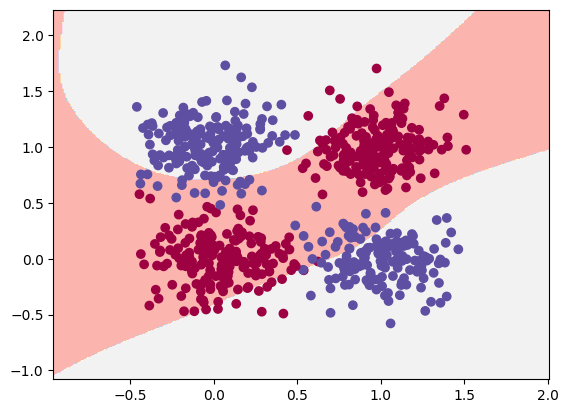

In [21]:
n0 = 2# input layer dimensionality
n1 = 100# hiden layer dimensionality
n2 = 2# output layer dimensionality
alpha = 0.1# learning rate for gradient descent
epochs = 10# number of iteration/epochs

# Build a model with 3 layers
myModel1 = MyNeuralNet(n0, n1, n2, alpha);
myModel1.fit(X_train, y_train, epochs, X_val, y_val)
print("Accuracy on the test set is ", myModel1.evaluate(X_test, y_test))

# Plot the decision boundary
myModel1.plot_decision_boundary(X_train, y_train)

Epoch 0/20 - loss: 5.705634 - accuracy: 0.493056 - val_loss: 5.659383 - val_accuracy: 0.462500
Epoch 10/20 - loss: 2.053584 - accuracy: 0.915278 - val_loss: 2.053871 - val_accuracy: 0.937500
Accuracy on the test set is  0.91


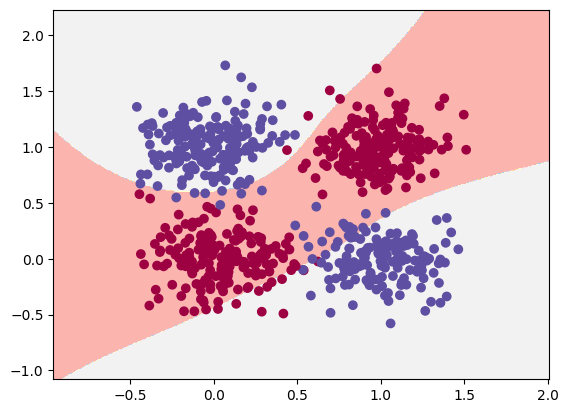

In [22]:
n0 = 2# input layer dimensionality
n1 = 100# hiden layer dimensionality
n2 = 2# output layer dimensionality
alpha = 0.1# learning rate for gradient descent
epochs = 20# number of iteration/epochs

# Build a model with 3 layers
myModel1 = MyNeuralNet(n0, n1, n2, alpha);
myModel1.fit(X_train, y_train, epochs, X_val, y_val)
print("Accuracy on the test set is ", myModel1.evaluate(X_test, y_test))

# Plot the decision boundary
myModel1.plot_decision_boundary(X_train, y_train)

Epoch 0/100 - loss: 5.705634 - accuracy: 0.493056 - val_loss: 5.659383 - val_accuracy: 0.462500
Epoch 10/100 - loss: 2.053584 - accuracy: 0.915278 - val_loss: 2.053871 - val_accuracy: 0.937500
Epoch 20/100 - loss: 2.311826 - accuracy: 0.944444 - val_loss: 2.318404 - val_accuracy: 0.950000
Epoch 30/100 - loss: 2.535666 - accuracy: 0.965278 - val_loss: 2.543452 - val_accuracy: 0.975000
Epoch 40/100 - loss: 2.726259 - accuracy: 0.970833 - val_loss: 2.733991 - val_accuracy: 0.975000
Epoch 50/100 - loss: 2.891964 - accuracy: 0.975000 - val_loss: 2.899230 - val_accuracy: 0.987500
Epoch 60/100 - loss: 3.038671 - accuracy: 0.976389 - val_loss: 3.045395 - val_accuracy: 0.987500
Epoch 70/100 - loss: 3.170499 - accuracy: 0.979167 - val_loss: 3.176734 - val_accuracy: 1.000000
Epoch 80/100 - loss: 3.290381 - accuracy: 0.980556 - val_loss: 3.296231 - val_accuracy: 1.000000
Epoch 90/100 - loss: 3.400466 - accuracy: 0.983333 - val_loss: 3.406044 - val_accuracy: 1.000000
Accuracy on the test set is  0.

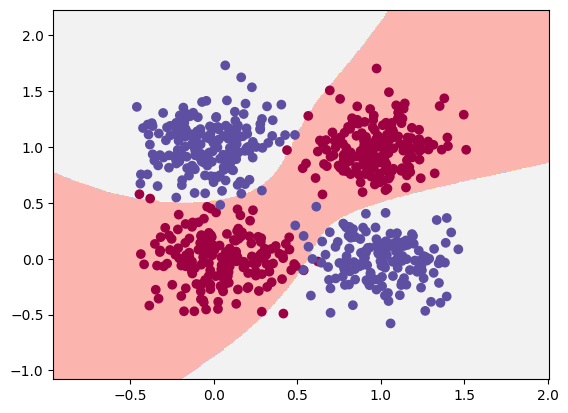

In [23]:
n0 = 2# input layer dimensionality
n1 = 100# hiden layer dimensionality
n2 = 2# output layer dimensionality
alpha = 0.1# learning rate for gradient descent
epochs = 100# number of iteration/epochs

# Build a model with 3 layers
myModel1 = MyNeuralNet(n0, n1, n2, alpha);
myModel1.fit(X_train, y_train, epochs, X_val, y_val)
print("Accuracy on the test set is ", myModel1.evaluate(X_test, y_test))

# Plot the decision boundary
myModel1.plot_decision_boundary(X_train, y_train)

---
# Get Help?
In case you get stuck in any step in the process, you may find some useful information from:

 * Consult my lecture slides on Module 2
 * Post your question in the Discussion tab under Assignment 1:...".

Part of the codes used in this assignment is modified from Konstantinos Kitsios under the 3-Clause BSD License. Best of luck and have fun!